<a href="https://colab.research.google.com/github/monaramezan-stack/Machine-Learning-projects/blob/main/Antenna_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Antenna s11 Parameter Estimation Using Machine Learning**

**Project**: The goal of this project is to Predict antenna reflection coefficient (S11 in dB) based on geometric design parameters and operating frequency.

**Dataset**: The dataset used in this project was generated using Ansys HFSS software to design and simulate microstrip patch antennas. The operating frequency is centered around 2.4 GHz, making it suitable for wireless applications such as Bluetooth and WLAN operations. 1266 samples from parametric simulation sweeps of 8 distinct patch antenna designs, varying slot geometry, across frequency bands from 1.0 - 3.5 GHz.

**Data Loading and Pre-processing**



In [44]:
import pandas as pd
file_name = "dataset_antenna.csv"
df = pd.read_csv(file_name)
df.columns
#Rename columns
df.columns = ["freq_ghz", "patch_length_mm", "patch_width_mm","slot_length_mm", "slot_width_mm", "s11_db"]
print("Dimensions of the dataset:" , df.shape)
df.head()


Dimensions of the dataset: (1266, 6)


,freq_ghz,patch_length_mm,patch_width_mm,slot_length_mm,slot_width_mm,s11_db
0,1.500000,33.0,33,0.0,0,-4.927274
1,1.551724,33.0,33,0.0,0,-5.077877
2,1.603448,33.0,33,0.0,0,-5.183708
3,1.655172,33.0,33,0.0,0,-5.215997
4,1.706897,33.0,33,0.0,0,-5.120009


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1266 entries, 0 to 1265
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   freq_ghz         1266 non-null   float64
 1   patch_length_mm  1266 non-null   float64
 2   patch_width_mm   1266 non-null   int64  
 3   slot_length_mm   1266 non-null   float64
 4   slot_width_mm    1266 non-null   int64  
 5   s11_db           1266 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 59.5 KB


In [46]:
df.describe()

,freq_ghz,patch_length_mm,patch_width_mm,slot_length_mm,slot_width_mm,s11_db
count,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000
mean,2.408768,39.636730,50.440758,19.399289,26.857820,-1.718475
std,0.604011,20.702096,34.846882,11.019903,16.369894,3.042243
min,1.000000,29.400000,26.000000,0.000000,0.000000,-34.533968
25%,1.910000,29.400000,38.000000,14.000000,24.000000,-1.387842
50%,2.410000,29.400000,38.000000,19.750000,24.000000,-0.744253
75%,2.900000,35.500000,38.000000,20.000000,28.000000,-0.596102
max,3.500000,87.000000,130.000000,85.000000,115.000000,-0.159236


### **Visualizing Dataset**

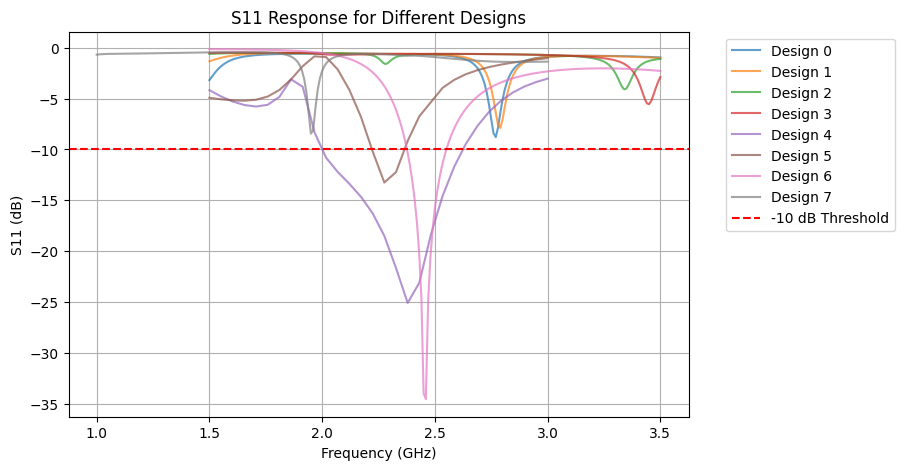

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
dataset_cols = ["patch_length_mm", "patch_width_mm", "slot_length_mm", "slot_width_mm"]
df["design_num"] = df.groupby(dataset_cols).ngroup()
plt.figure(figsize=(8, 5))
for design_num, group in df.groupby("design_num"):
    plt.plot(group["freq_ghz"], group["s11_db"], label=f"Design {design_num}", alpha=0.7)
plt.axhline(-10, color='red', linestyle='--', label='-10 dB Threshold')
plt.xlabel("Frequency (GHz)")
plt.ylabel("S11 (dB)")
plt.title("S11 Response for Different Designs")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

## **Data Spliting**

In [48]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=['s11_db'])
y=df['s11_db']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
X_tr.shape, X_te.shape



((1012, 6), (254, 6))

## **Linear Regression Model**

,Metric,Train,Test,CV Mean
0,MSE,6.924434,5.592628,-
1,R2 Score,0.261444,0.360011,0.23066


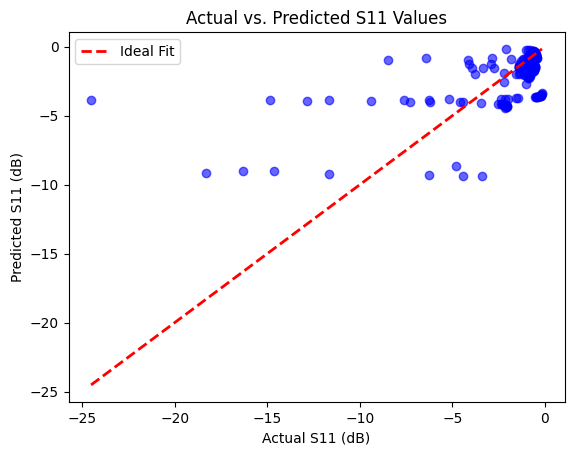

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
lr_model = LinearRegression()
lr_scores = cross_val_score(lr_model, X_tr, y_tr, cv=5, scoring='r2')
lr_model.fit(X_tr, y_tr)
slope = lr_model.coef_[4]
intercept = lr_model.intercept_
lr_model.coef_
y_te_pred = lr_model.predict(X_te)
y_tr_pred = lr_model.predict(X_tr)
mse_tr = mean_squared_error(y_tr, y_tr_pred)
mse_te_lr = mean_squared_error(y_te, y_te_pred)
r2_tr = r2_score(y_tr, y_tr_pred)
r2_te = r2_score(y_te, y_te_pred)
results = {
    "Metric": ["MSE", "R2 Score"],
    "Train": [mse_tr, r2_tr],
    "Test": [mse_te_lr, r2_te],
    "CV Mean":['-', lr_scores.mean()]
}
results_df = pd.DataFrame(results)
display(results_df)
plt.scatter(y_te, y_te_pred, alpha=0.6, color='blue')
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel("Actual S11 (dB)")
plt.ylabel("Predicted S11 (dB)")
plt.title("Actual vs. Predicted S11 Values")
plt.legend()
plt.show()



Since Linear Regression assumes a linear relationship, it cannot model the non-linear relationship between the antenna parameters and the $S_{11}$ values very well. Therefore, **Random Forest** and **XGBoost** are used to improve prediction accuracy

# **Random Forest Model**

In [50]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_tr, y_tr)
rf_scores = cross_val_score(rf_model, X_tr, y_tr, cv=5, scoring='r2')
y_pred = rf_model.predict(X_te)
y_tr_pred = rf_model.predict(X_tr)
mse_te = mean_squared_error(y_te, y_pred)
r2_te_rf = r2_score(y_te, y_pred)
mse_tr = mean_squared_error(y_tr, y_tr_pred)
r2_tr = r2_score(y_tr, y_tr_pred)
mse_te,r2_te
results = {
    "Metric": ["MSE", "R2 Score"],
    "Train": [mse_tr, r2_tr],
    "Test": [mse_te, r2_te_rf],
    "CV Mean":['-', rf_scores.mean()]
}
results_df = pd.DataFrame(results)
display(results_df)


,Metric,Train,Test,CV Mean
0,MSE,0.073884,0.217387,-
1,R2 Score,0.992120,0.975123,0.923952


**Feature Importance Analysis**

In [51]:
importances = rf_model.feature_importances_
feature_names = X_tr.columns
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)
feat_imp


,Feature,Importance
0,freq_ghz,0.628261
2,patch_width_mm,0.204358
3,slot_length_mm,0.054368
4,slot_width_mm,0.053628
5,design_num,0.039538
1,patch_length_mm,0.019847


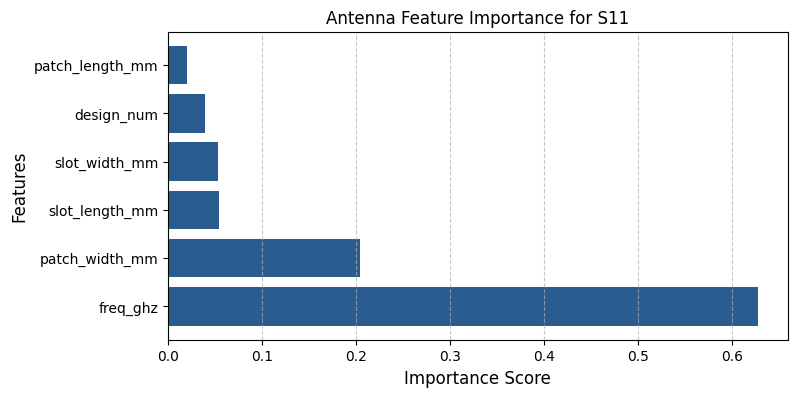

In [52]:
plt.figure(figsize=(8, 4))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#2b5c8f')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Antenna Feature Importance for S11')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Based on the evaluation metrics, Random Forest performs better than Linear Regression. It models the non-linear relationship between the antenna parameters and the $S_{11}$ values more effectively, resulting in a higher $R^2$ score and lower prediction error.

## **XGBoost Model**

,Metric,Train,Test,CV Mean
0,MSE,0.018516,0.524369,-
1,R2 Score,0.998025,0.939994,0.884972


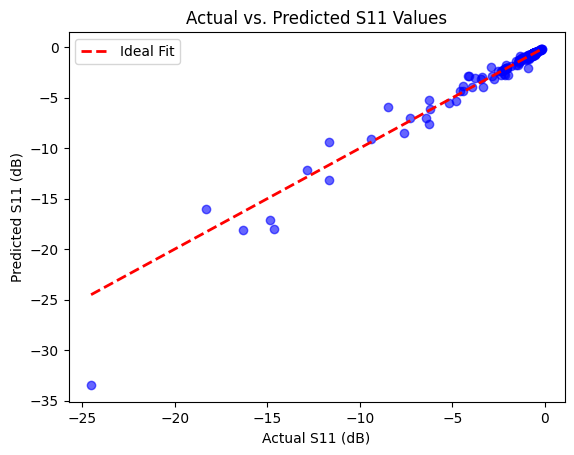

In [53]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_scores = cross_val_score(xgb_model, X_tr, y_tr, cv=5, scoring='r2')
xgb_model.fit(X_tr, y_tr)
y_pred_xgb = xgb_model.predict(X_te)
mse_xgb = mean_squared_error(y_te, y_pred_xgb)
y_tr_pred = xgb_model.predict(X_tr)
r2_xgb = r2_score(y_te, y_pred_xgb)
mse_tr = mean_squared_error(y_tr, y_tr_pred)
r2_tr = r2_score(y_tr, y_tr_pred)
results = {
    "Metric": ["MSE", "R2 Score"],
    "Train": [mse_tr, r2_tr],
    "Test": [mse_xgb, r2_xgb],
    "CV Mean":['-', xgb_scores.mean()]
}
results_df = pd.DataFrame(results)
display(results_df)
plt.scatter(y_te, y_pred_xgb, alpha=0.6, color='blue')
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel("Actual S11 (dB)")
plt.ylabel("Predicted S11 (dB)")
plt.title("Actual vs. Predicted S11 Values")
plt.legend()
plt.show()
importances = xgb_model.feature_importances_
feature_names = X_tr.columns
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)


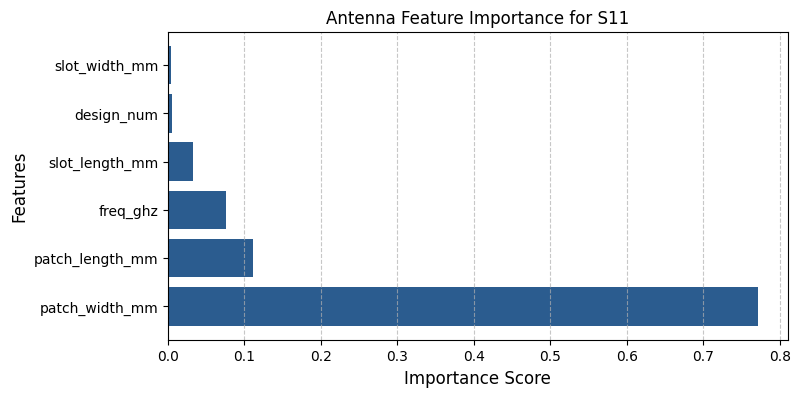

In [54]:
plt.figure(figsize=(8, 4))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#2b5c8f')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Antenna Feature Importance for S11')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## **Model Evaluationand Comparison**

In [55]:
comparison = {
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "Test MSE": [mse_te_lr, mse_te, mse_xgb],
    "Test R2": [r2_te, r2_te_rf, r2_xgb],
    "CV Mean R2": [lr_scores.mean(), rf_scores.mean(), xgb_scores.mean()]
}

comparison_df = pd.DataFrame(comparison)
display(comparison_df)

,Model,Test MSE,Test R2,CV Mean R2
0,Linear Regression,5.592628,0.360011,0.230660
1,Random Forest,0.217387,0.975123,0.923952
2,XGBoost,0.524369,0.939994,0.884972


### Conclusion
In this study, three machine learning models, **Linear Regression**, **Random Forest**, and **XGBoost**, were used to predict the S11 frequency response and return loss of the antenna.

The results showed that **Linear Regression** could not model the complex nonlinear relationship between the antenna parameters very well. Therefore, it had higher prediction error and lower R² values.

On the other hand, **Random Forest** and **XGBoost** performed much better. Both models were able to learn the nonlinear patterns in the data and produced more accurate predictions.

Among all models, **Random Forest** gave the best overall results. It achieved a test R² of about **0.975** and a cross-validation mean R² of **0.923**, which indicates good accuracy and reliable performance on unseen data.

Based on these results, Random Forest is selected as the most suitable model for predicting S11 parameters in this antenna design study.